In [711]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax

from probjax.distributions import MultivariateNormal
from probjax.core.jaxpr_propagation.graph import JaxprGraph

import matplotlib.pyplot as plt

from sbi.analysis import pairplot

In [716]:
input_dim = 1
output_dim = 1
hidden_dim = 2
key1, key2, key3, key4, key5, key6 = jrandom.split(jrandom.PRNGKey(0), 6)
params = [(jrandom.normal(key1,shape=(hidden_dim, input_dim)), jrandom.normal(key2,shape=(hidden_dim,))),(jrandom.normal(key2,shape=(hidden_dim, hidden_dim)), jrandom.normal(key3,shape=(hidden_dim,))), (jrandom.normal(key4,shape=(output_dim, hidden_dim)), jrandom.normal(key5,shape=(output_dim,)))]

params = jax.tree_map(lambda x: jax.nn.sigmoid(x), params)
def f(params, x):
    for W, b in params:
        x = W@x + b
        x = jnp.tanh(x)
    return x


In [717]:
def inverse_matrix_vector_multiplication(A):
    eps = jnp.finfo(A.dtype).eps
    m,n = A.shape
    d = min(m,n)
    # SVD
    U, s, V_T = jnp.linalg.svd(A)
    # Filter out very small singular values
    s_inv = jnp.where(s > eps, 1/s, 0)
    is_zero = jnp.concatenate([s < eps, jnp.ones(n - d, dtype=bool)])



    # Orhtonormal basis of the null space
    basis = V_T[is_zero,:]
    # Pseudo inverse
    pseudo_inverse = V_T.T[:,:d] @ (jnp.diag(s_inv) @ U.T[:d,:])


    # Produces an independent sample from the solution space
    def sample_solution(param, b):
        x_star = pseudo_inverse @ b
        noise = basis.T @ param
        return x_star + noise
    
    def init_param(key):
        return jrandom.normal(key, (basis.shape[0],))*0.1

    return init_param, sample_solution 

In [722]:
def create_finv(key, params):
    new_params = []
    apply_fn = []
    for W, b in params[::-1]:
        key, subkey = jrandom.split(key)
        init_param, sample_solution = inverse_matrix_vector_multiplication(W)
        new_params.append(init_param(subkey))
        apply_fn.append(sample_solution)


    def f_inv(new_params, y):
        error = 0.
        for theta, (W, b), fn in zip(new_params, params[::-1],apply_fn):
            x = jnp.copy(y)
            y = jnp.clip(y, -1 + 1e-6, 1- 1e-6)
            error += jnp.mean((x - y)**2)
            x2 = jnp.copy(y)
            y = jnp.arctanh(y)
            y = y - b
            y = fn(theta, y)

            print(x, error)
            # print(jnp.mean((x - 10*jnp.tanh((W@y + b)))**2))
            # print(jnp.mean((x2 - 10*jnp.tanh(W@y + b))**2))

        return y, error
        
    return f_inv, new_params

f_inv, new_params = create_finv(jrandom.PRNGKey(0), params)

In [723]:

from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions import Normal, Uniform
from probjax.distributions.independent import Independent
from probjax.core import inverse_and_logabsdet, inverse
from probjax.core.jaxpr_propagation.graph import JaxprGraph
from probjax.nn.bijective import rational_quadratic_spline
import matplotlib.pyplot as plt

import haiku as hk
from probjax.nn.coupling import CouplingMLP
from probjax.nn.autoregressive import AutoregressiveMLP, MaskedMLP, autoregressive_mask_getter
from probjax.nn.helpers import Flip, Permute

import optax
from optax import adam

import jax
from jax import numpy as jnp


@jax.vmap
def affine_bijector(loc_and_scale, x):
    loc, scale = jnp.split(loc_and_scale, 2, axis=-1)
    scale = jax.nn.softplus(scale) + 0.5
    return loc + scale*x

context_dim = 1
flow_input_dim = 4
bijector_dim = 2*(flow_input_dim // 2)
split_dim = flow_input_dim // 2

@hk.without_apply_rng
@hk.transform
def forward(x, context):
    nn = hk.Sequential([CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context),
                        Flip(), 
                        CouplingMLP(split_dim, affine_bijector, bijector_dim, context=context)])
    return nn(x)

params_flow = forward.init(jax.random.PRNGKey(0), jnp.zeros((1, flow_input_dim)), jnp.zeros((1, context_dim)))

# Parameterized invertibe transformation
T = forward.apply
p = Independent(Normal(jnp.zeros(flow_input_dim), jnp.ones(flow_input_dim)), reinterpreted_batch_ndims=1)
q = TransformedDistribution(p, lambda x: T(params_flow, x, jnp.zeros((1, context_dim))))

In [724]:
def sample_new_params(key, params_flow, context, sample_shape):
    q = TransformedDistribution(p, lambda x: T(params_flow, x, context))
    theta1 = q.rsample(key = key, sample_shape=sample_shape)  
    return theta1

In [710]:
sample_new_params(jrandom.PRNGKey(42), params_flow, jnp.zeros((10, context_dim)), sample_shape=(10,))

Array([[ 0.19 ,  0.009,  0.105,  1.454],
       [ 0.604, -0.73 ,  1.244,  1.256],
       [-0.987, -0.529,  2.351,  0.54 ],
       [ 3.128, -1.046,  1.242,  3.323],
       [ 0.348, -2.683,  0.407,  1.909],
       [ 2.666, -0.072, -3.102, -1.942],
       [ 1.936,  1.456,  1.283,  2.883],
       [ 2.179, -0.715,  2.369, -2.686],
       [-2.859, -0.674,  2.059,  1.539],
       [-0.701, -0.763,  1.998, -0.859]], dtype=float32)

In [734]:
W, b = params[1]

V, s, U = jnp.linalg.svd(W)
pseudo_inverse = U.T @ jnp.diag(1/s) @ V.T

In [740]:
pseudo_inverse@jnp.arctanh(jnp.array([0.987, 0.499]))

Array([ 7.805, -1.577], dtype=float32)

In [742]:
pseudo_inverse

Array([[ 4.261, -5.308],
       [-1.297,  3.072]], dtype=float32)

In [741]:
jnp.arctanh(jnp.array([0.987, 0.499]))

Array([2.515, 0.548], dtype=float32)

In [725]:
x = jax.random.uniform(jrandom.PRNGKey(42), (1,))
y = f(params, x)

x_inv, error = f_inv(new_params, y)
print(x, x_inv, error)

[0.883] 0.0
[0.987 0.499] 0.0
[ 7.489 -2.17 ] 21.7407
[0.427] [10.722] 21.7407


In [721]:
new_params

[Array([-0.125], dtype=float32),
 Array([], dtype=float32),
 Array([], dtype=float32)]

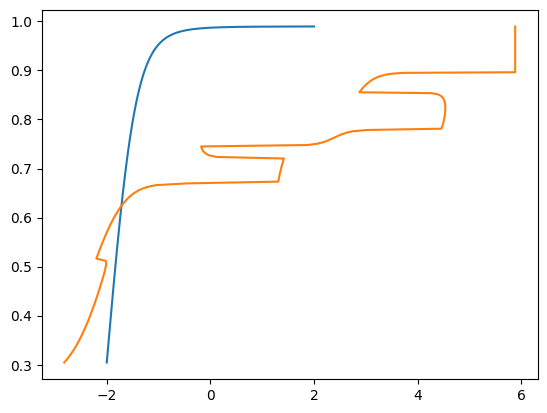

In [689]:
xs = jnp.linspace(-2, 2, 1000)
ys = jax.vmap(f, in_axes=(None, 0))(params, xs.reshape(-1,1))
xs_rec, errors = jax.vmap(f_inv, in_axes=(None, 0))(new_params, ys.reshape(-1,1))
plt.plot(xs, ys)
plt.plot(xs_rec, ys)

In [690]:
def loss_fn(flow_params, key, x,y):
    theta1 = sample_new_params(key, flow_params, y, sample_shape=(y.shape[0],))
    x_inv, error = jax.vmap(f_inv, in_axes=(0, 0))([theta1, jnp.empty([theta1.shape[0],0]),jnp.empty([theta1.shape[0],0])], y)
    return jnp.mean((x_inv - x)**2) + jnp.mean(error)

In [691]:
loss_fn(params_flow, jrandom.PRNGKey(42), xs, ys)

Array(15557.205, dtype=float32)

In [692]:
import optax
optimizer = optax.adam(1e-3)

@jax.jit
def step(params, opt_state,key, x,y):
    loss, g = jax.value_and_grad(loss_fn)(params,key, x, y)
    updates, updated_state = optimizer.update(g, opt_state)
    new_params = optax.apply_updates(params, updates)

    return new_params, updated_state, loss

xs = jnp.linspace(-2, 2, 1000)
ys = jax.vmap(f, in_axes=(None, 0))(params, xs.reshape(-1,1))

In [694]:
opt_state = optimizer.init(params_flow)
key = jrandom.PRNGKey(42)
for i in range(10000):
    key, subkey = jrandom.split(key)
    params_flow, opt_state, loss = step(params_flow, opt_state, subkey, xs,ys)
    if i % 1000 == 0:
        print(loss)

940.9468
853.8947


KeyboardInterrupt: 

In [695]:
ys.shape

(1000, 1)

[1272.85  1295.548 1318.175 1329.672 1333.074 1343.446 1285.297 1332.361
 1248.761  947.997 1222.832 1227.231  995.369 1233.453 1242.309 1197.655
 1287.126 1227.022 1252.207 1192.791 1231.421 1250.505  381.685 1175.054
 1199.283 1213.453 1218.406 1201.904 1206.464 1203.367 1149.98  1153.454
 1112.963 1207.521  900.221  978.246 1172.344  916.425 1116.122 1109.264
 1083.216 1136.813 1057.889 1160.149 1119.64  1223.791 1139.601 1119.054
 1071.599 1054.377 1120.297 1132.381 1036.299 1098.789 1136.759 1042.246
 1050.102 1047.491 1063.523 1122.307 1073.134 1038.259 1048.947  921.052
 1043.657 1031.181 1020.933 1014.394 1026.836  989.858 1052.3   1011.908
 1035.35  1034.456 1033.661 1093.827  970.62  1011.75   987.256 1004.173
 1025.613 1019.637  997.048  961.307  981.11   967.215  930.331 1024.896
  991.211  977.22   982.396  940.515  948.44   943.     983.68   949.504
  959.512  923.813  959.507  949.813  927.645  923.118  953.765  918.424
  930.659  939.571  919.765  913.605  901.766  908.

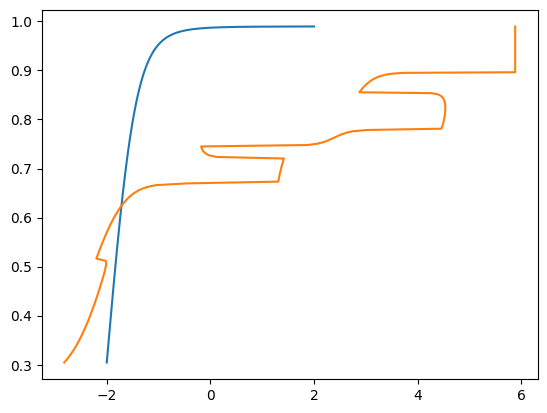

In [703]:
xs = jnp.linspace(-2, 2, 1000)
ys = jax.vmap(f, in_axes=(None, 0))(params, xs.reshape(-1,1))
theta1 = sample_new_params(key, params_flow, ys,(1000,))
x_rec, error = jax.vmap(f_inv, in_axes=(0, 0))([theta1, jnp.empty([theta1.shape[0],0]),jnp.empty([theta1.shape[0],0])], ys)
plt.plot(xs, ys)
plt.plot(xs_rec, ys)
print(error)